In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
image2 = cv2.imread('img.jpg')
image2_gray = cv2.cvtColor(image2, cv2.COLOR_BGR2GRAY) 

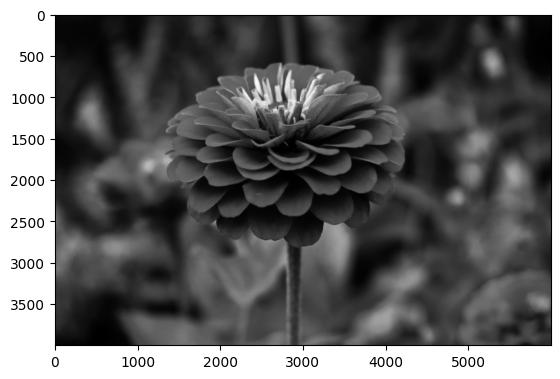

In [3]:
plt.imshow(image2_gray, cmap="gray")

In [4]:
# Gaussian noise
mean = 0
stddev = 150
noise_gauss = np.zeros(image2_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

array([[  0,  24,   0, ..., 224,  84,   0],
       [129,   0, 255, ...,   0,   0,  54],
       [ 59, 159,   0, ...,   0, 255,   0],
       ...,
       [  0,   0,  53, ...,   0,  53, 208],
       [  0,   0,   0, ...,   0, 160,   0],
       [153,   0,   0, ...,   0, 100,   0]],
      shape=(4000, 6000), dtype=uint8)

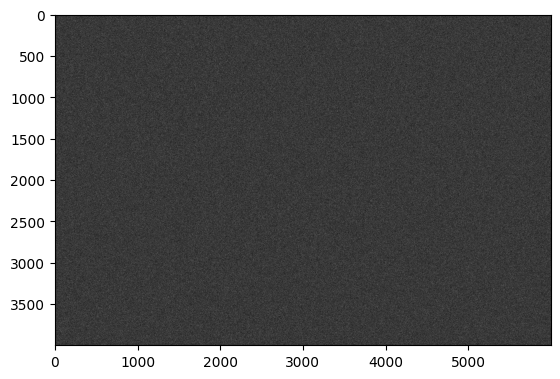

In [5]:
plt.imshow(noise_gauss, cmap="gray")

In [6]:
image2_noise_gauss = cv2.add(image2_gray,noise_gauss)

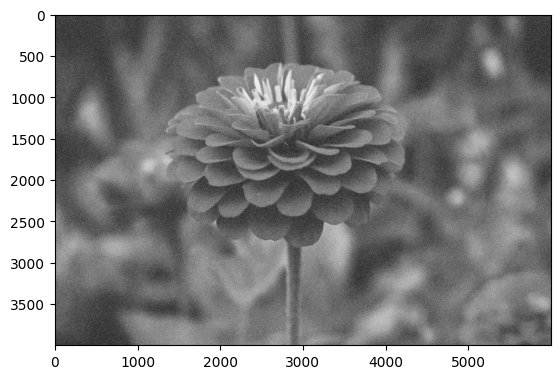

In [7]:
plt.imshow(image2_noise_gauss, cmap="gray")

In [15]:
low = -50
high = 50
noise_uniform = np.random.uniform(low, high, image2_gray.shape).astype(np.uint8)
noise_uniform_image = np.clip(image2_gray.astype(np.uint8) + noise_uniform, 0, 255).astype(np.uint8)

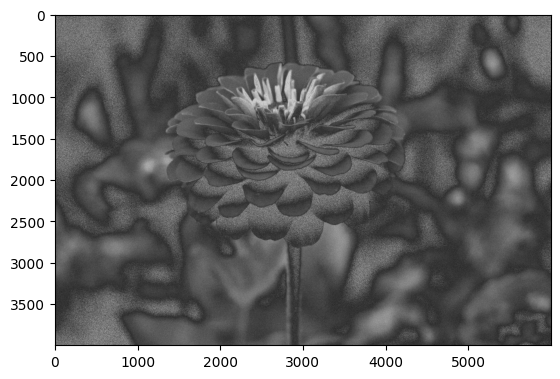

In [16]:
plt.imshow(noise_uniform_image, cmap="gray")

 ПРИМЕНЕНИЕ ФИЛЬТРОВ С РАЗЛИЧНЫМИ ПАРАМЕТРАМИ ДЛЯ ГАУССОВСКИЙ ШУМА


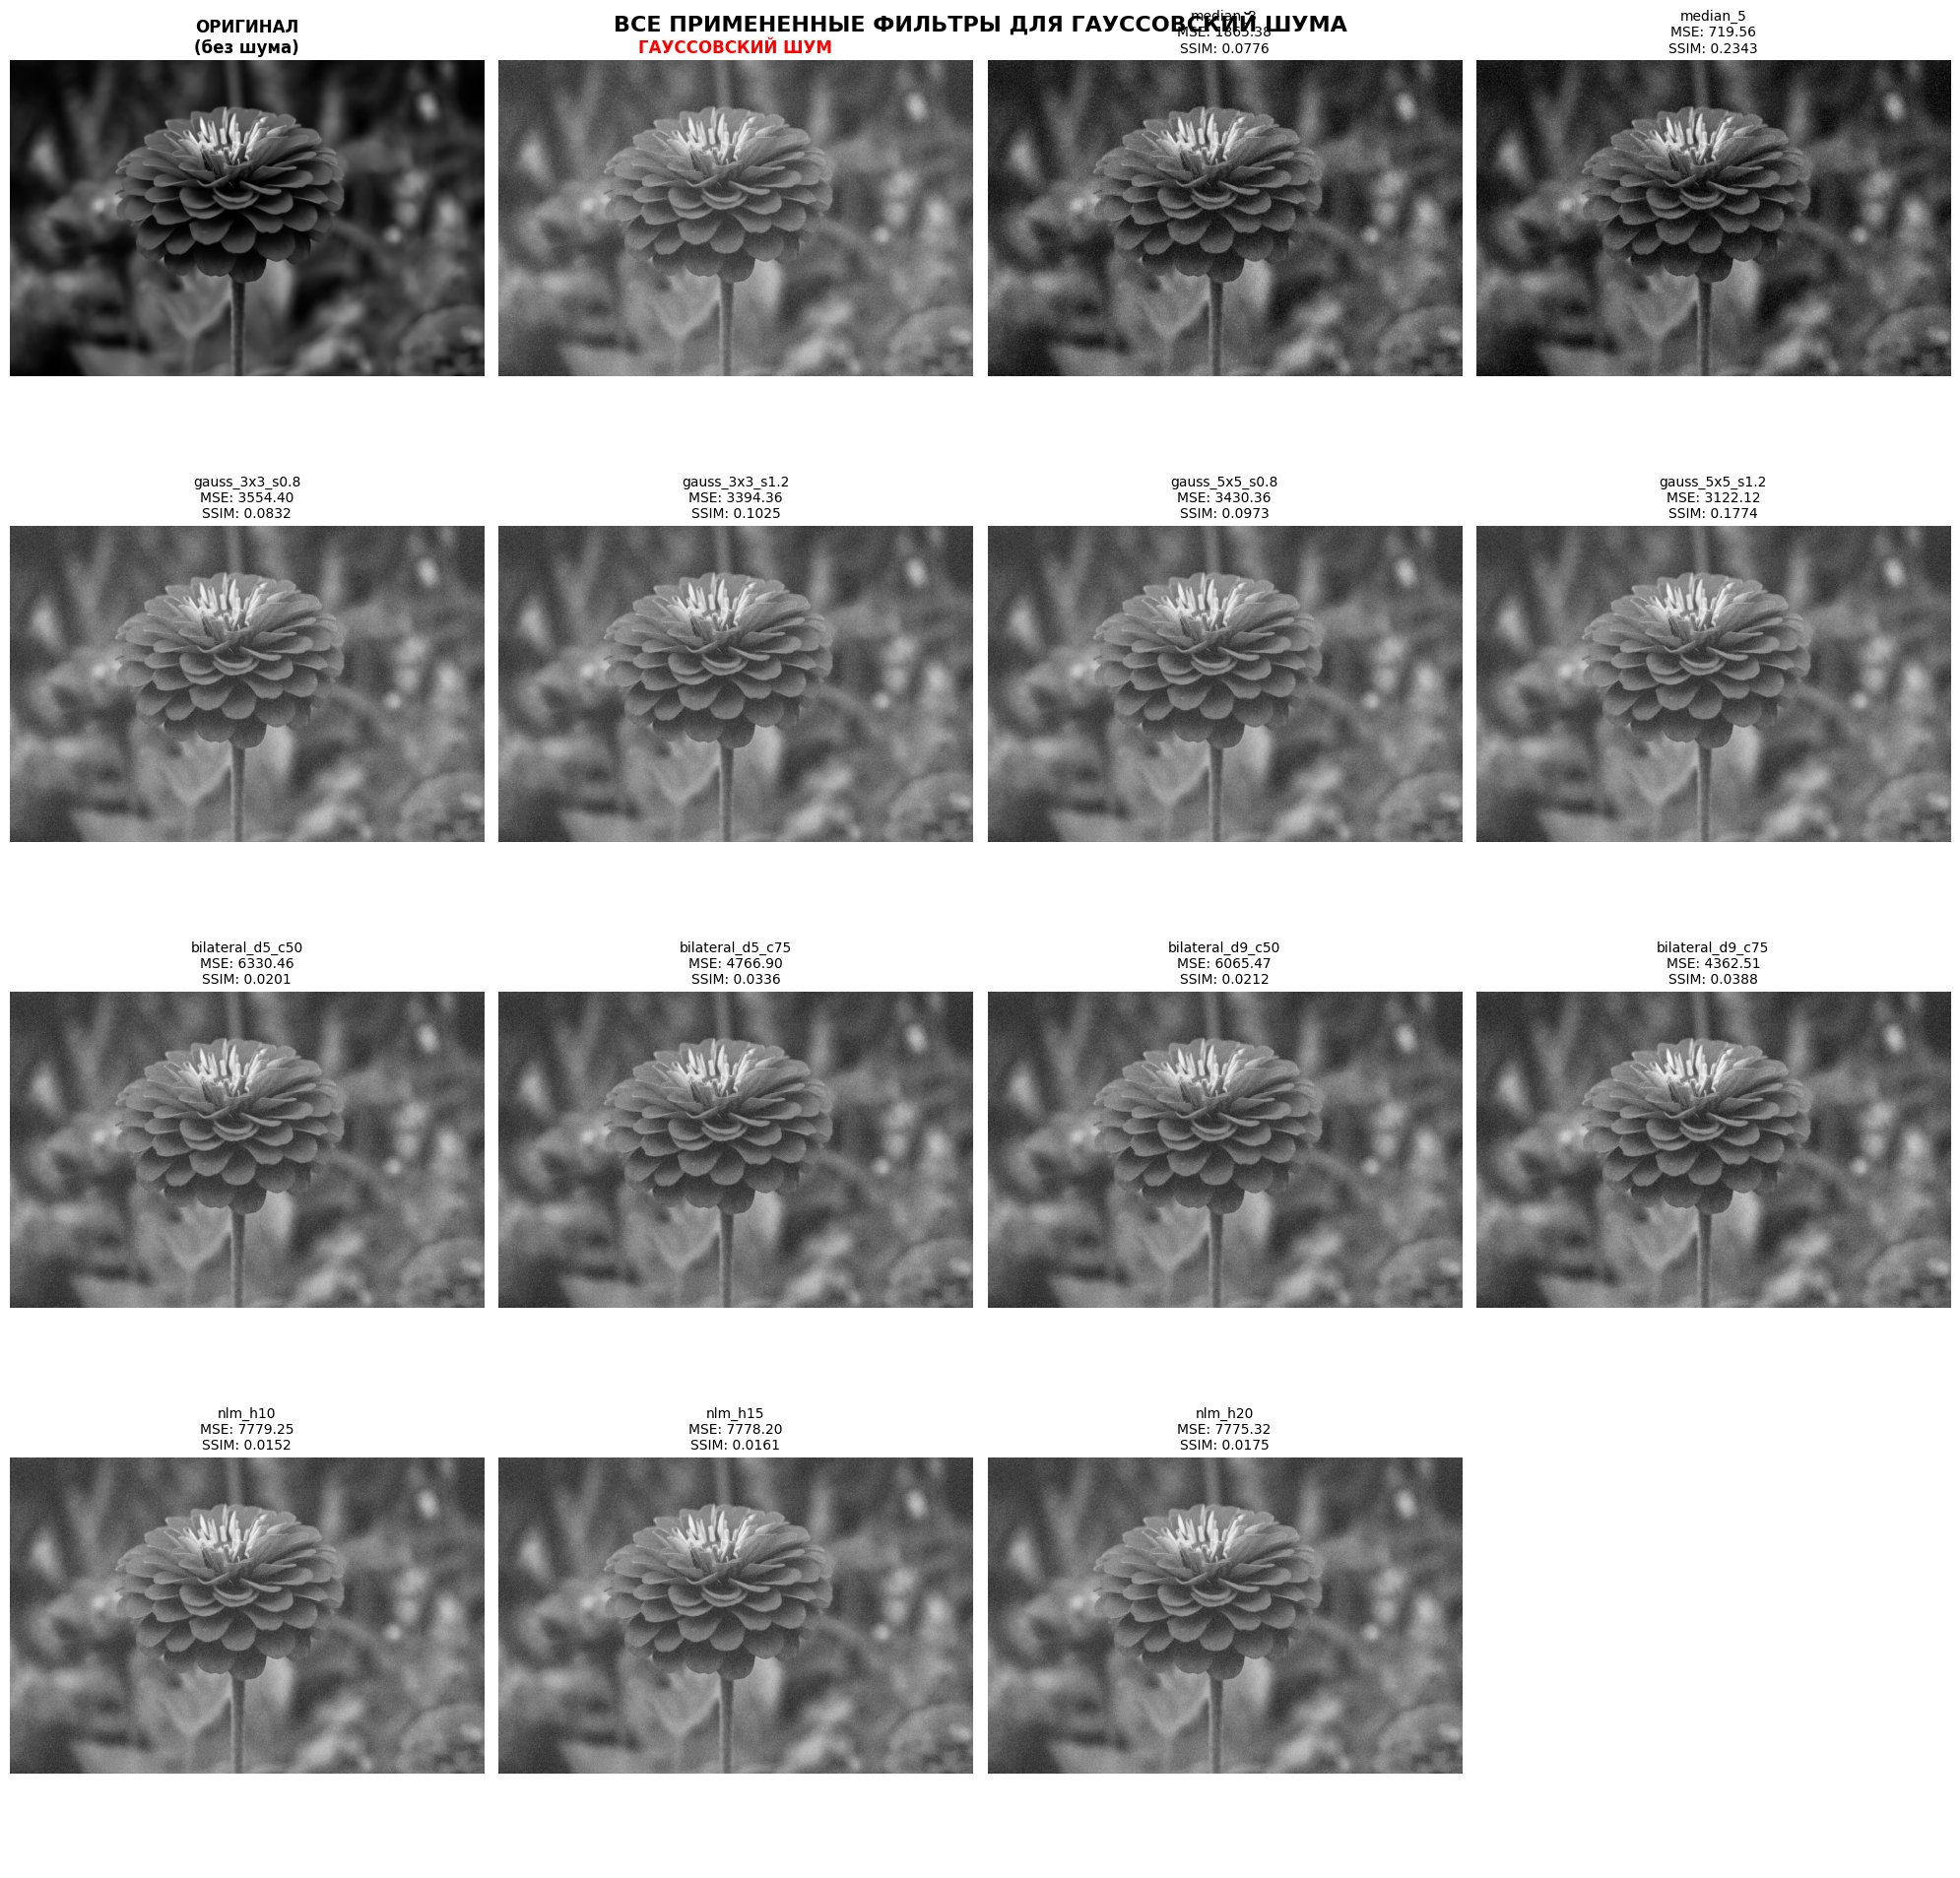

АНАЛИЗ ЛУЧШИХ ФИЛЬТРОВ ДЛЯ ГАУССОВСКИЙ ШУМА

 ЛУЧШИЙ ПО SSIM:
   Фильтр: median_5
   SSIM = 0.2343 (чем ближе к 1.0, тем лучше)
   MSE = 719.5571

 ЛУЧШИЙ ПО MSE:
   Фильтр: median_5
   MSE = 719.5571 (чем меньше, тем лучше)
   SSIM = 0.2343


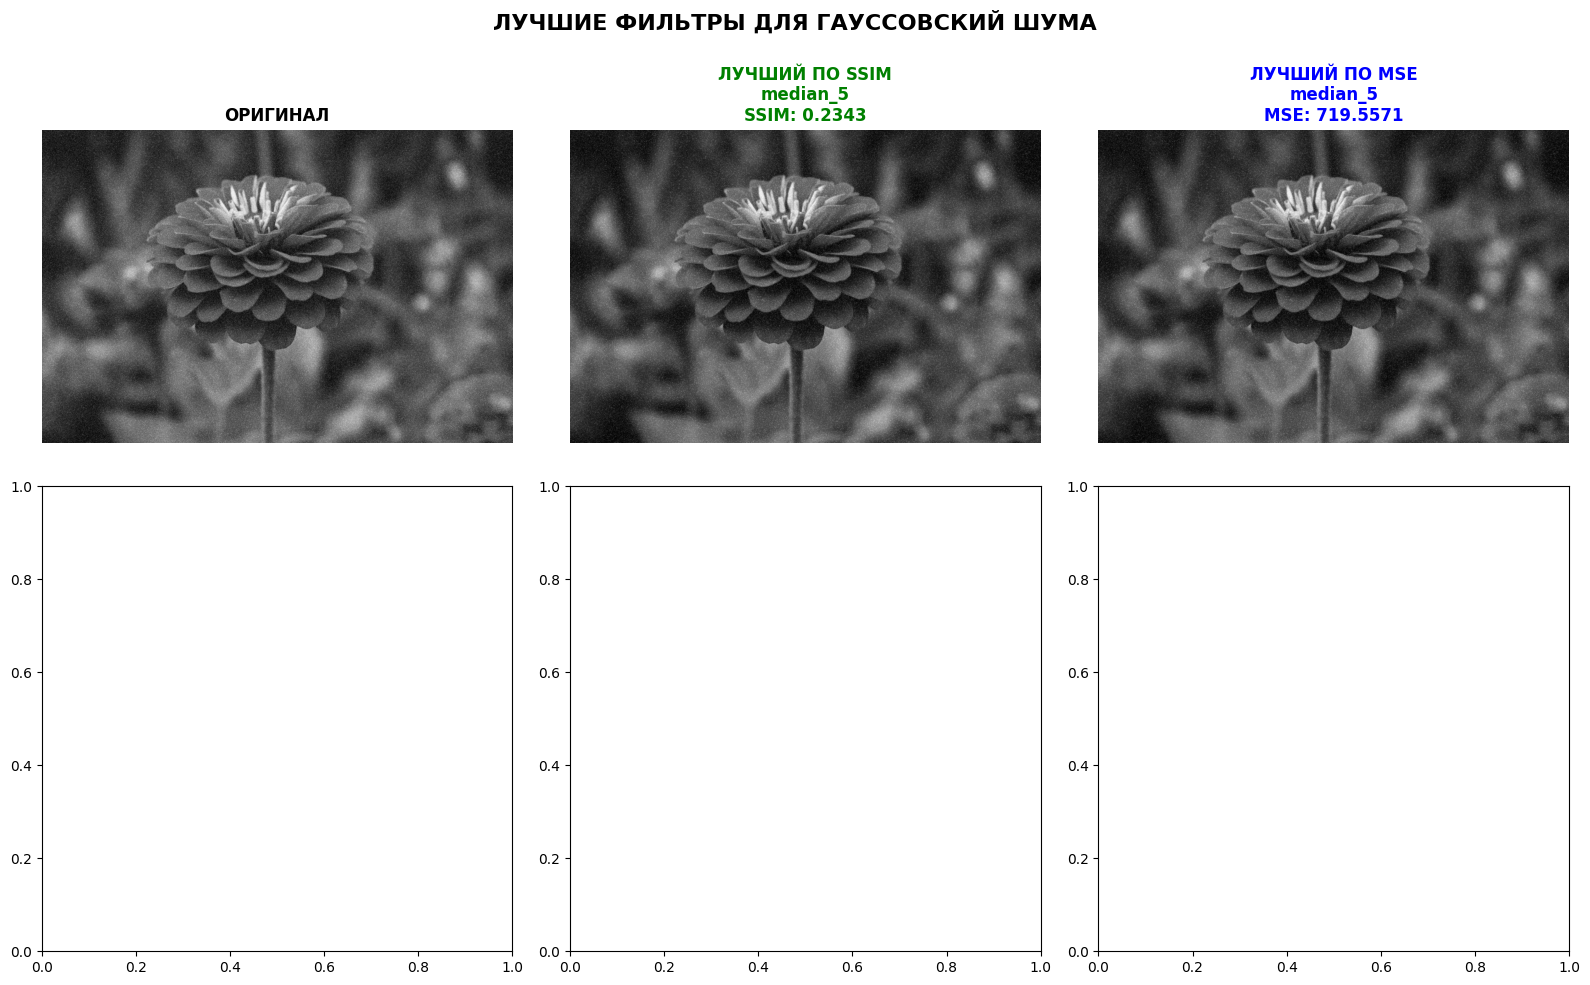

 ПРИМЕНЕНИЕ ФИЛЬТРОВ С РАЗЛИЧНЫМИ ПАРАМЕТРАМИ ДЛЯ РАВНОМЕРНЫЙ ШУМА


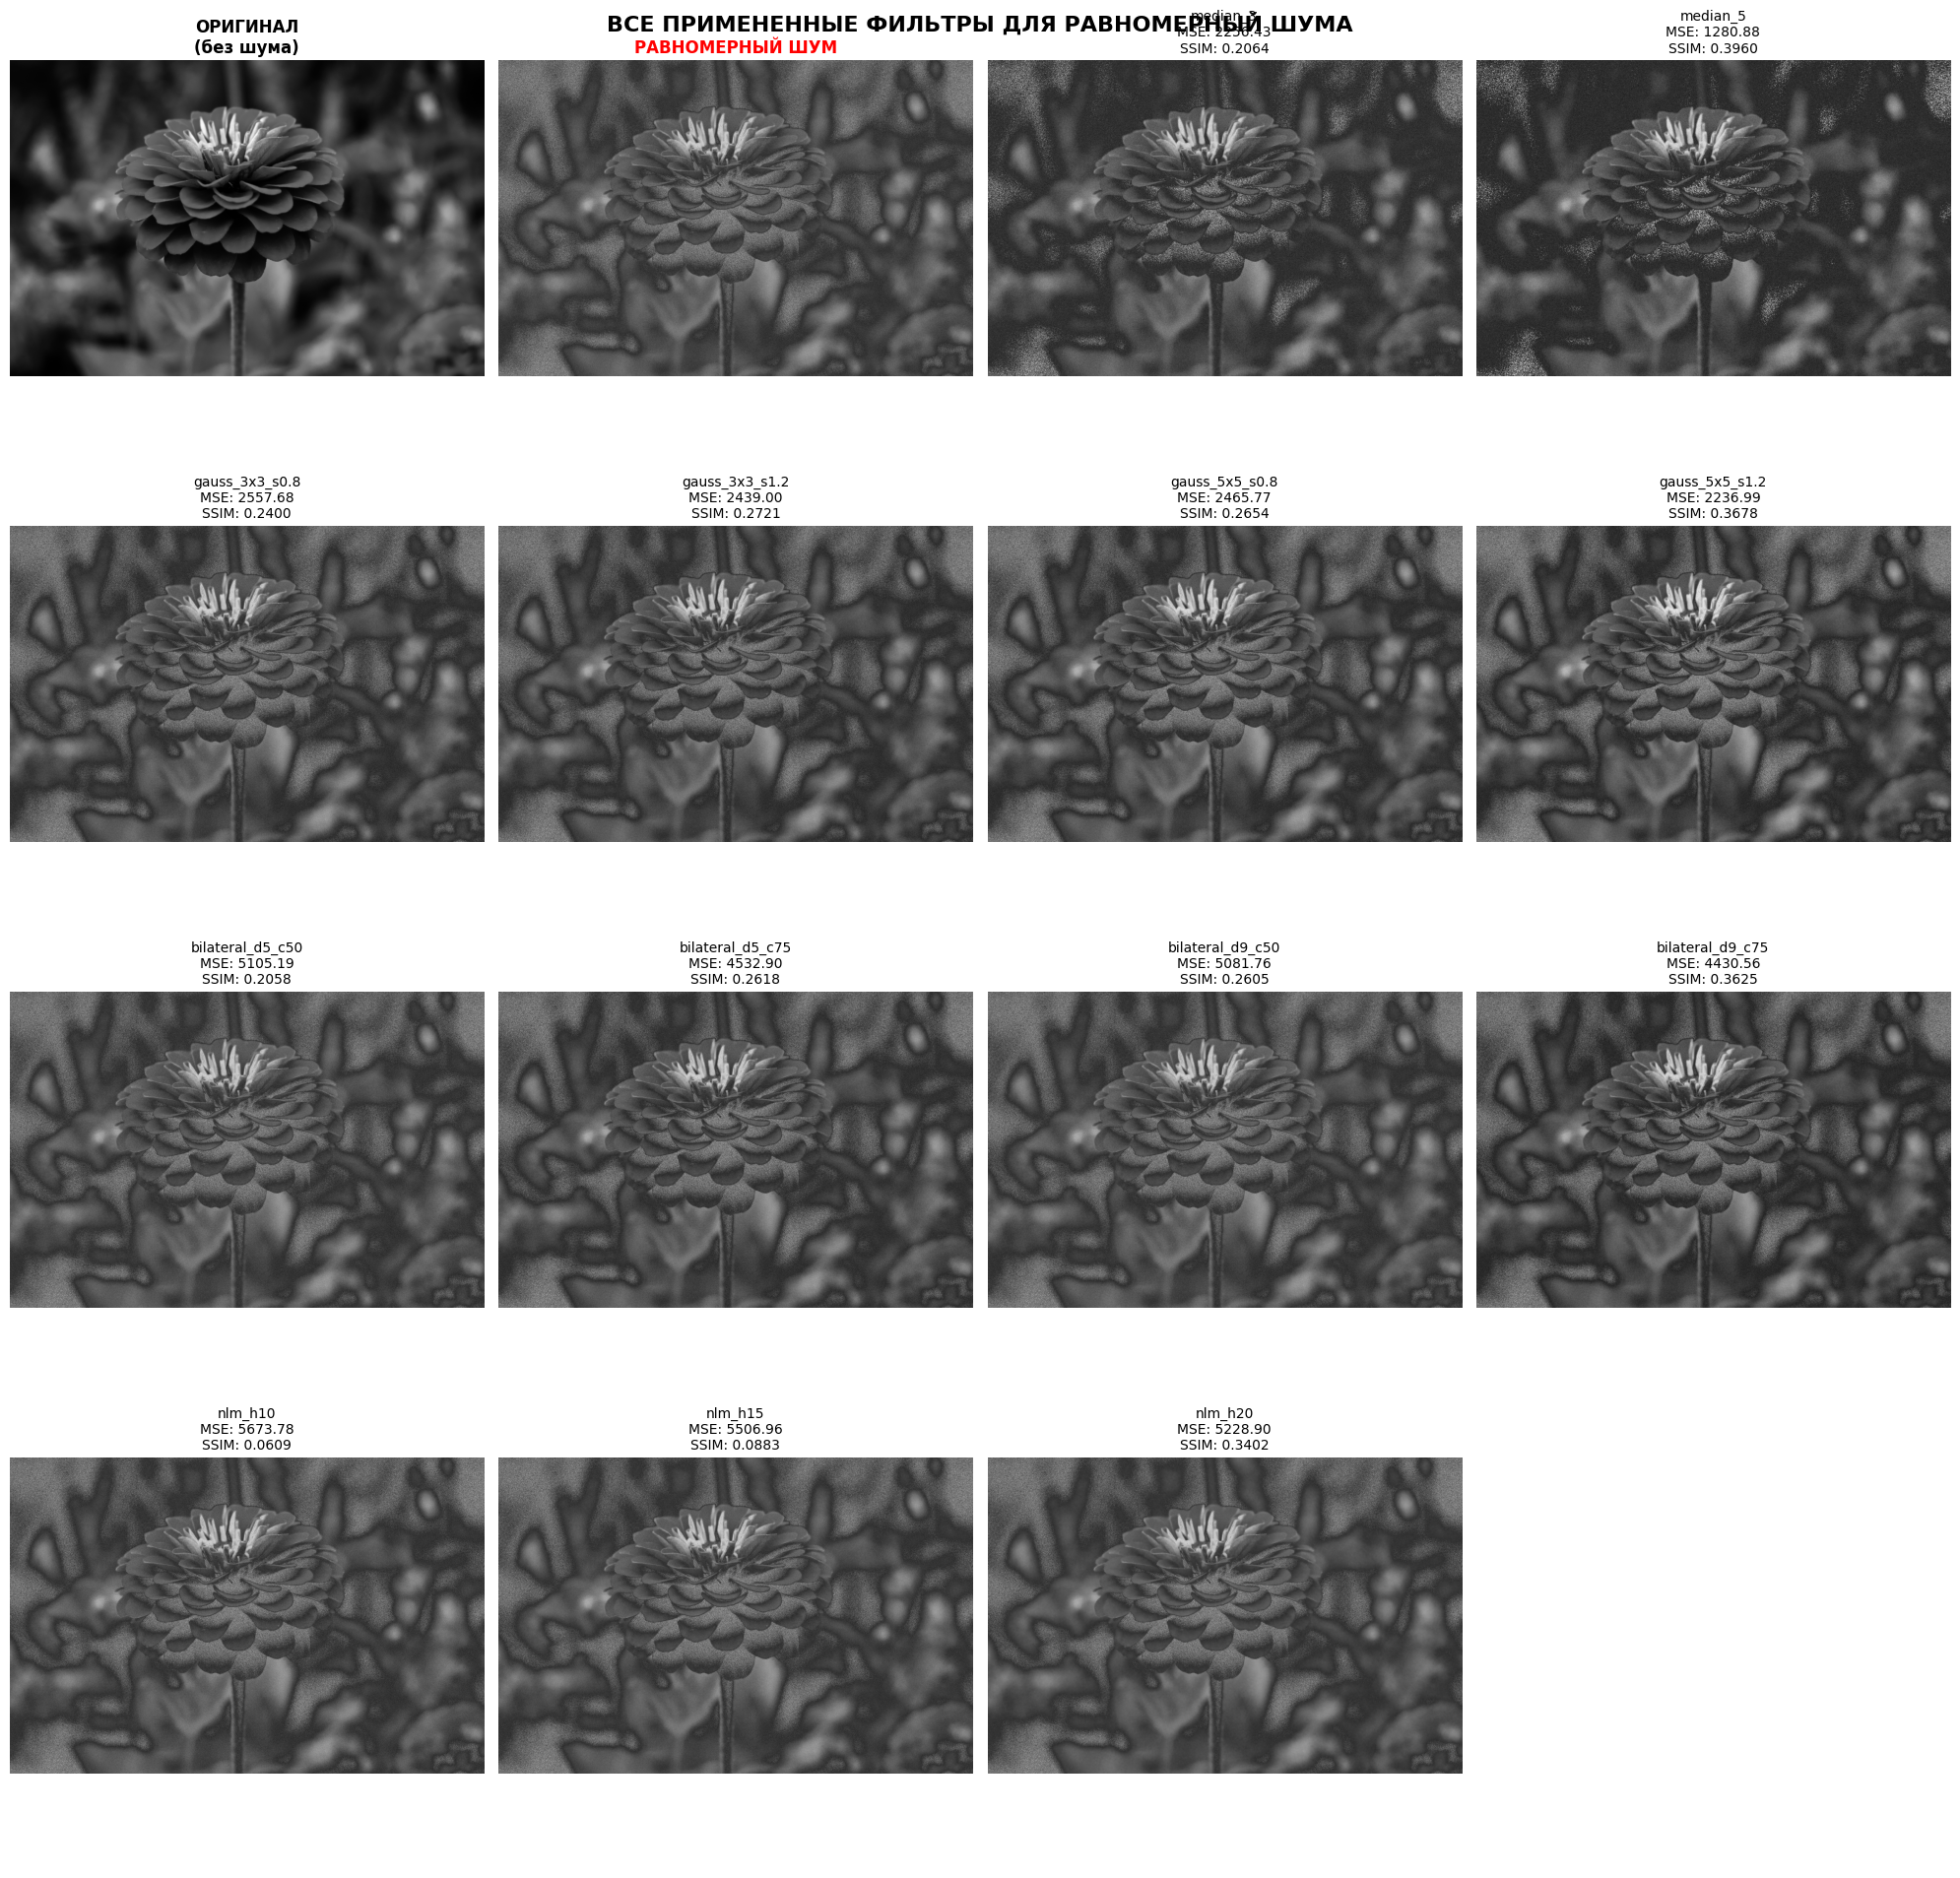

АНАЛИЗ ЛУЧШИХ ФИЛЬТРОВ ДЛЯ РАВНОМЕРНЫЙ ШУМА

 ЛУЧШИЙ ПО SSIM:
   Фильтр: median_5
   SSIM = 0.3960 (чем ближе к 1.0, тем лучше)
   MSE = 1280.8783

 ЛУЧШИЙ ПО MSE:
   Фильтр: median_5
   MSE = 1280.8783 (чем меньше, тем лучше)
   SSIM = 0.3960


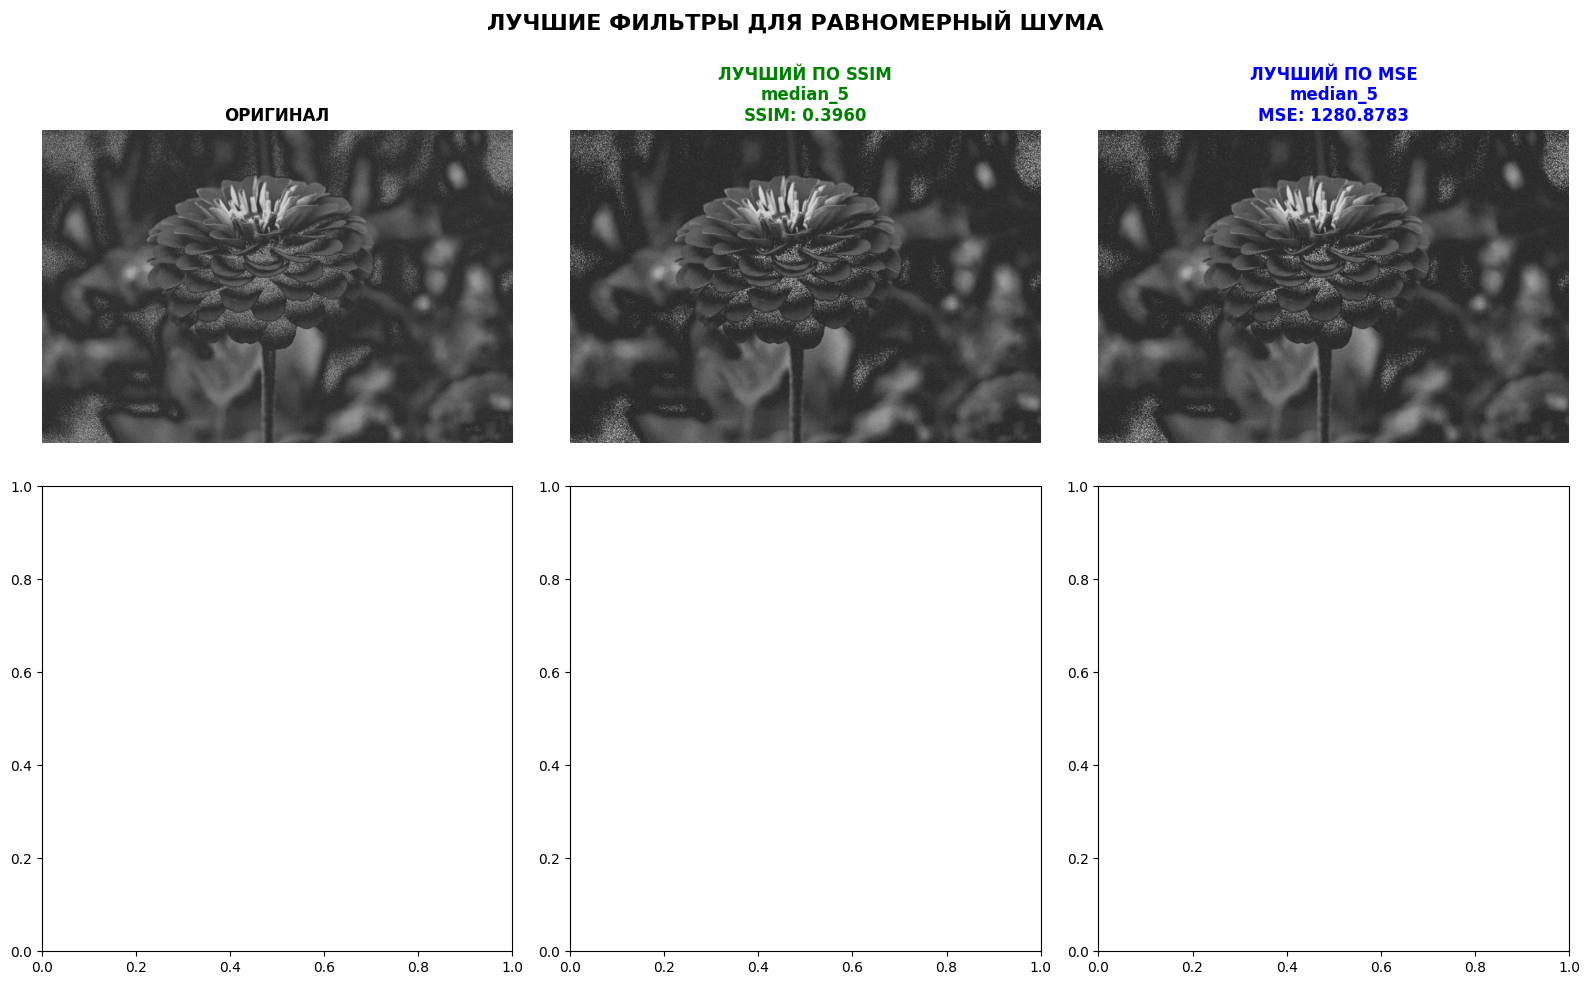

In [ ]:
from skimage.metrics import structural_similarity, mean_squared_error
import cv2
import matplotlib.pyplot as plt

def test_filters_detailed(noisy, original, name=""):
    results = {}
    
    
    print(f" ПРИМЕНЕНИЕ ФИЛЬТРОВ С РАЗЛИЧНЫМИ ПАРАМЕТРАМИ ДЛЯ {name.upper()} ШУМА")
    
    
    
    
    median_params = [3, 5]
    for size in median_params:
        median = cv2.medianBlur(noisy, size)
        mse = mean_squared_error(original, median)
        ssim = structural_similarity(original, median)
        results[f"median_{size}"] = (median, mse, ssim)
        

    
    
    gauss_params = [(3,3), (5,5)]
    sigma_params = [0.8, 1.2]
    
    for kernel in gauss_params:
        for sigma in sigma_params:
            gauss = cv2.GaussianBlur(noisy, kernel, sigma)
            mse = mean_squared_error(original, gauss)
            ssim = structural_similarity(original, gauss)
            results[f"gauss_{kernel[0]}x{kernel[1]}_s{sigma}"] = (gauss, mse, ssim)
            

    
    
    d_params = [5, 9]
    sigma_color_params = [50, 75]
    
    for d in d_params:
        for sigma_color in sigma_color_params:
            bilateral = cv2.bilateralFilter(noisy, d, sigma_color, sigma_color)
            mse = mean_squared_error(original, bilateral)
            ssim = structural_similarity(original, bilateral)
            results[f"bilateral_d{d}_c{sigma_color}"] = (bilateral, mse, ssim)
            

    
    
    h_params = [10, 15, 20]
    
    for h in h_params:
        nlm = cv2.fastNlMeansDenoising(noisy, None, h, 7, 21)
        mse = mean_squared_error(original, nlm)
        ssim = structural_similarity(original, nlm)
        results[f"nlm_h{h}"] = (nlm, mse, ssim)
        

    
    visualize_all_filters(original, noisy, results, name)
    
    return results

def visualize_all_filters(original, noisy, results, name):
    
    n_filters = len(results)
    n_cols = 4
    n_rows = (n_filters + 2) // n_cols + 1  
    
    fig, axs = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
    axs = axs.flatten()
    
   
    axs[0].imshow(original, cmap="gray")
    axs[0].set_title("ОРИГИНАЛ\n(без шума)", fontweight='bold')
    axs[0].axis('off')
    
    axs[1].imshow(noisy, cmap="gray")
    axs[1].set_title(f"{name.upper()} ШУМ", fontweight='bold', color='red')
    axs[1].axis('off')
    
    
    for i, (filter_name, (img, mse, ssim)) in enumerate(results.items(), 2):
        if i < len(axs):
            axs[i].imshow(img, cmap="gray")
            axs[i].set_title(f"{filter_name}\nMSE: {mse:.2f}\nSSIM: {ssim:.4f}", 
                           fontsize=10)
            axs[i].axis('off')
    
    
    for i in range(len(results) + 2, len(axs)):
        axs[i].axis('off')
    
    plt.suptitle(f"ВСЕ ПРИМЕНЕННЫЕ ФИЛЬТРЫ ДЛЯ {name.upper()} ШУМА", 
                fontsize=16, fontweight='bold', y=0.95)
    plt.tight_layout()
    plt.show()

def analyze_best_filters(results, name):
    
    
    print(f"АНАЛИЗ ЛУЧШИХ ФИЛЬТРОВ ДЛЯ {name.upper()} ШУМА")
    
    
    
    results_list = [(key, mse, ssim) for key, (img, mse, ssim) in results.items()]
    
    
    best_ssim = max(results_list, key=lambda x: x[2])
    
    best_mse = min(results_list, key=lambda x: x[1])
    
    print(f"\n ЛУЧШИЙ ПО SSIM:")
    print(f"   Фильтр: {best_ssim[0]}")
    print(f"   SSIM = {best_ssim[2]:.4f}")
    print(f"   MSE = {best_ssim[1]:.4f}")
    
    print(f"\n ЛУЧШИЙ ПО MSE:")
    print(f"   Фильтр: {best_mse[0]}")
    print(f"   MSE = {best_mse[1]:.4f} ")
    print(f"   SSIM = {best_mse[2]:.4f}")
    
       
    
    visualize_best_filters(results, best_ssim, best_mse, name)
    
    return best_ssim, best_mse

def visualize_best_filters(results, best_ssim, best_mse, name):
    
    fig, axs = plt.subplots(2, 3, figsize=(16, 10))
    
    
    best_ssim_img = results[best_ssim[0]][0]
    best_mse_img = results[best_mse[0]][0]
    
    
    axs[0,0].imshow(results[list(results.keys())[0]][0], cmap="gray") 
    axs[0,0].set_title("ОРИГИНАЛ", fontweight='bold')
    axs[0,0].axis('off')
    
    axs[0,1].imshow(best_ssim_img, cmap="gray")
    axs[0,1].set_title(f"ЛУЧШИЙ ПО SSIM\n{best_ssim[0]}\nSSIM: {best_ssim[2]:.4f}", 
                      fontweight='bold', color='green')
    axs[0,1].axis('off')
    
    axs[0,2].imshow(best_mse_img, cmap="gray")
    axs[0,2].set_title(f"ЛУЧШИЙ ПО MSE\n{best_mse[0]}\nMSE: {best_mse[1]:.4f}", 
                      fontweight='bold', color='blue')
    axs[0,2].axis('off')
    
    
    
    
    plt.suptitle(f"ЛУЧШИЕ ФИЛЬТРЫ ДЛЯ {name.upper()} ШУМА", 
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()




results_gauss = test_filters_detailed(image2_noise_gauss, image2_gray, "Гауссовский")


best_gauss_ssim, best_gauss_mse = analyze_best_filters(results_gauss, "Гауссовский")


results_uniform = test_filters_detailed(noise_uniform_image, image2_gray, "Равномерный")


best_uniform_ssim, best_uniform_mse = analyze_best_filters(results_uniform, "Равномерный")



